# **Sales Analysis**

In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
eda_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [4]:
eda_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
572510,2025-06-29 14:27:32.496721,2025,6,Sun,Afternoon,Yes,Richard Jennings,Male,56,55-64,VIP,Canada,Completed,Electronics,Tablets,236.00,Luxury,1,Single,236.00,47.20,20,Medium Discount,Yes,188.80,Medium,82.34,43.61,Apple Pay,Economy,5.97,3.16,11,Slow,Canada,Domestic,5,64.10,Medium,Yes,23.30,Medium,3,Yes,9.80,Low,Desktop,Affiliate,Search
260174,2025-11-24 14:10:44.281084,2025,11,Mon,Afternoon,No,Brandon Anderson,Male,20,18-24,Regular,France,Completed,Clothing,Kids Wear,132.16,Premium,4,Bulk,528.64,79.30,15,Medium Discount,Yes,449.34,High,168.18,37.43,Credit Card,Next Day,21.49,4.78,14,Slow,France,Domestic,5,75.40,High,Yes,28.60,Medium,1,Yes,75.50,High,Mobile,Affiliate,Referral
179852,2024-09-09 01:43:02.698785,2024,9,Mon,Night,No,Isaiah Gomez,Male,26,25-34,Regular,Canada,Completed,Home,Decor,120.06,Premium,5,Bulk,600.30,150.07,25,High Discount,Yes,450.23,High,66.88,14.85,Credit Card,Express,6.08,1.35,13,Slow,Canada,Domestic,4,42.00,Medium,No,55.90,High,2,No,72.80,High,Desktop,Organic,Direct
390104,2024-04-13 19:57:14.152452,2024,4,Sat,Evening,Yes,James Bennett,Male,43,35-44,Regular,Italy,Completed,Home,Bedding,20.27,Budget,1,Single,20.27,4.05,20,Medium Discount,Yes,16.22,Low,2.25,13.87,Apple Pay,Next Day,3.51,21.64,3,Fast,Italy,Domestic,2,51.70,Medium,No,43.40,High,20,Yes,4.90,Low,Tablet,Facebook,Social
872703,2024-03-01 04:33:45.584174,2024,3,Fri,Night,No,Eric Roberts,Male,62,55-64,Regular,United Kingdom,Completed,Health,Fitness,134.05,Premium,2,Small Basket,268.10,13.40,5,Low Discount,Yes,254.70,Medium,97.16,38.15,Debit Card,Express,1.45,0.57,14,Slow,United Kingdom,Domestic,4,80.90,High,Yes,32.40,Medium,10,Yes,69.30,Medium,Mobile,Google Ads,Email
820723,2025-11-11 04:03:48.517577,2025,11,Tue,Night,No,Brandon Gonzalez,Male,19,18-24,Regular,United Kingdom,Pending,Health,Fitness,99.36,Mid-Range,4,Bulk,397.44,0.00,0,No Discount,No,397.44,High,201.52,50.70,PayPal,Express,16.50,4.15,6,Standard,United Kingdom,Domestic,1,8.50,Low,No,28.10,Medium,2,No,59.80,Medium,Desktop,Facebook,Search
367051,2025-11-23 17:05:45.168755,2025,11,Sun,Afternoon,Yes,Jeffrey Stevens,Male,66,65+,Premium,Australia,Completed,Clothing,Kids Wear,93.31,Mid-Range,5,Bulk,466.55,0.00,0,No Discount,No,466.55,High,213.55,45.77,Debit Card,Economy,20.36,4.36,14,Slow,Australia,Domestic,5,61.10,Medium,Yes,50.60,High,1,Yes,28.80,Low,Tablet,Facebook,Search
619291,2024-05-13 19:44:04.704393,2024,5,Mon,Evening,No,Trevor Moreno,Male,69,65+,Regular,Germany,Cancelled,Electronics,Tablets,117.40,Premium,3,Small Basket,352.20,35.22,10,Low Discount,Yes,316.98,High,91.56,28.89,PayPal,Next Day,13.64,4.30,10,Slow,Germany,Domestic,5,20.80,Low,Yes,48.80,High,4,No,78.90,High,Tablet,Organic,Email
137368,2025-05-31 00:26:38.682714,2025,5,Sat,Night,Yes,Tanya Gray,Female,51,45-54,Regular,United Kingdom,Completed,Clothing,Shoes,85.73,Mid-Range,2,Small Basket,171.46,25.72,15,Medium Discount,Yes,145.74,Medium,34.28,23.52,Debit Card,Standard,21.38,14.67,7,Standard,United Kingdom,Domestic,2,63.30,Medium,Yes,43.20,High,2,Yes,98.70,High,Tablet,Affiliate,Email
181889,2025-03-29 12:54:42.696237,2025,3,Sat,Afternoon,Yes,Angela Cain,Female,53,45-54,Regular,United States,Completed,Sports,Outdoor,80.34,Mid-Range,3,Small Basket,241.02,24.10,10,Low Discount,Yes,216.92,Medium,67.40,31.07,PayPal,Express,2.98,1.37,1

## 1.1 Revenue by Time

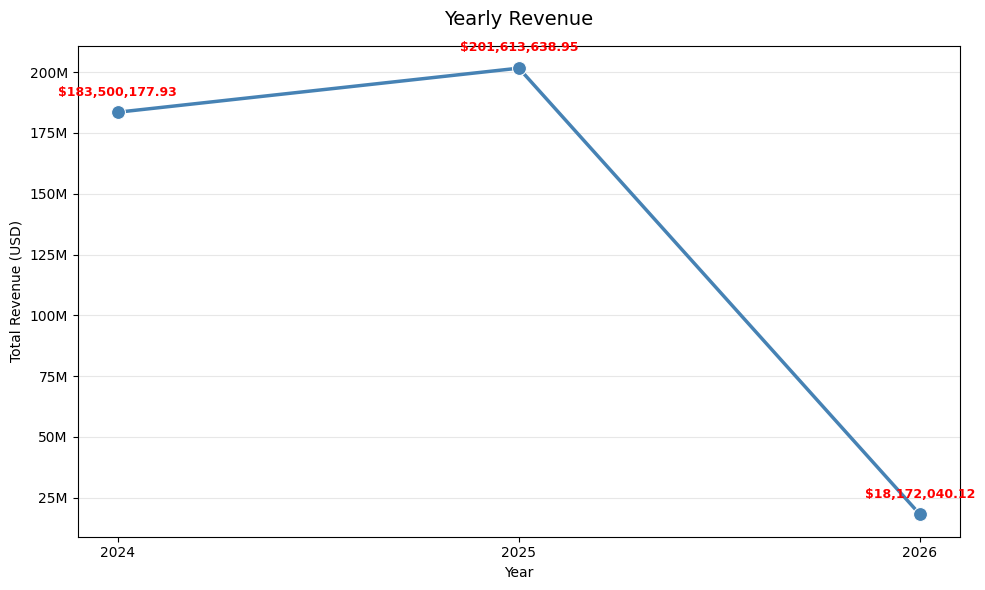

In [5]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    eda_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

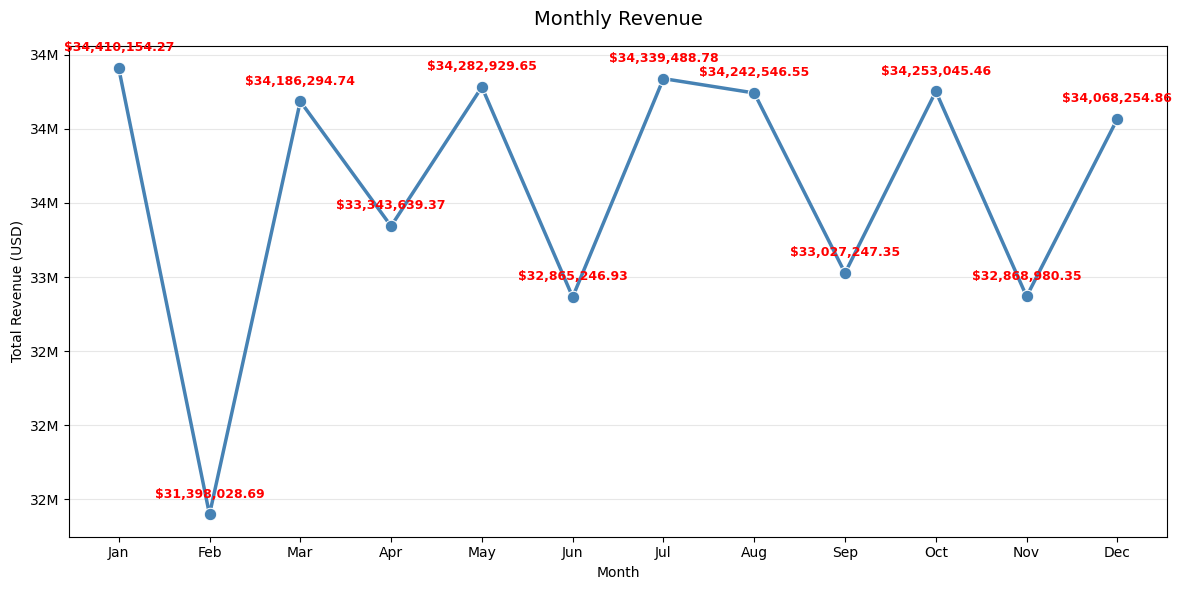

In [6]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

eda_df['order_month'] = eda_df['order_month'].map(month_map)

monthly_revenue = (
    eda_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

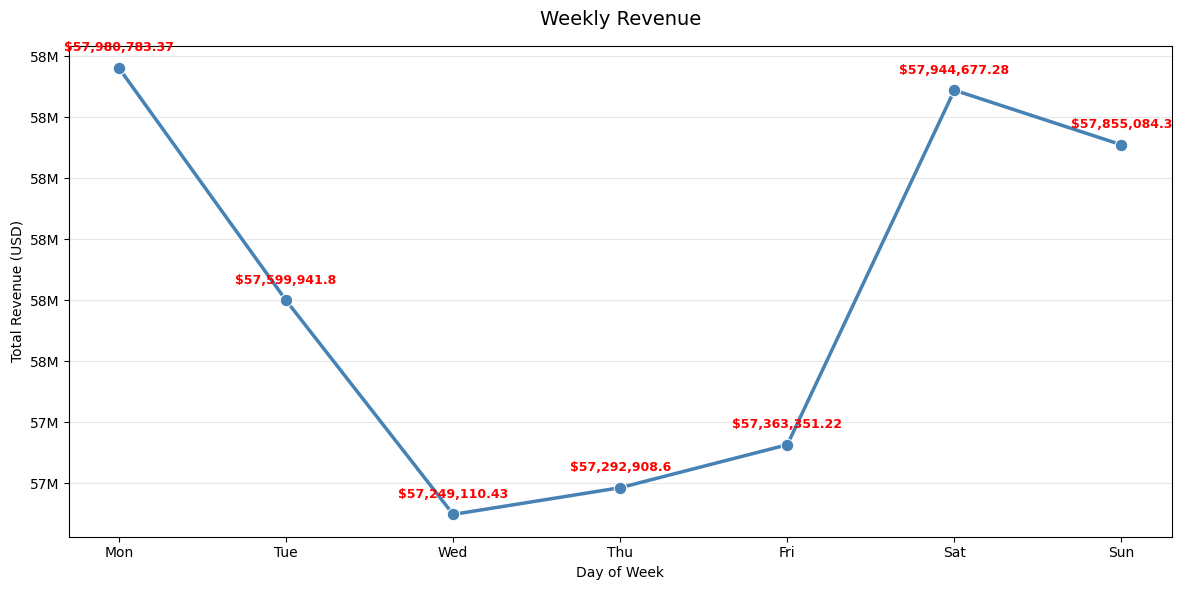

In [7]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    eda_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

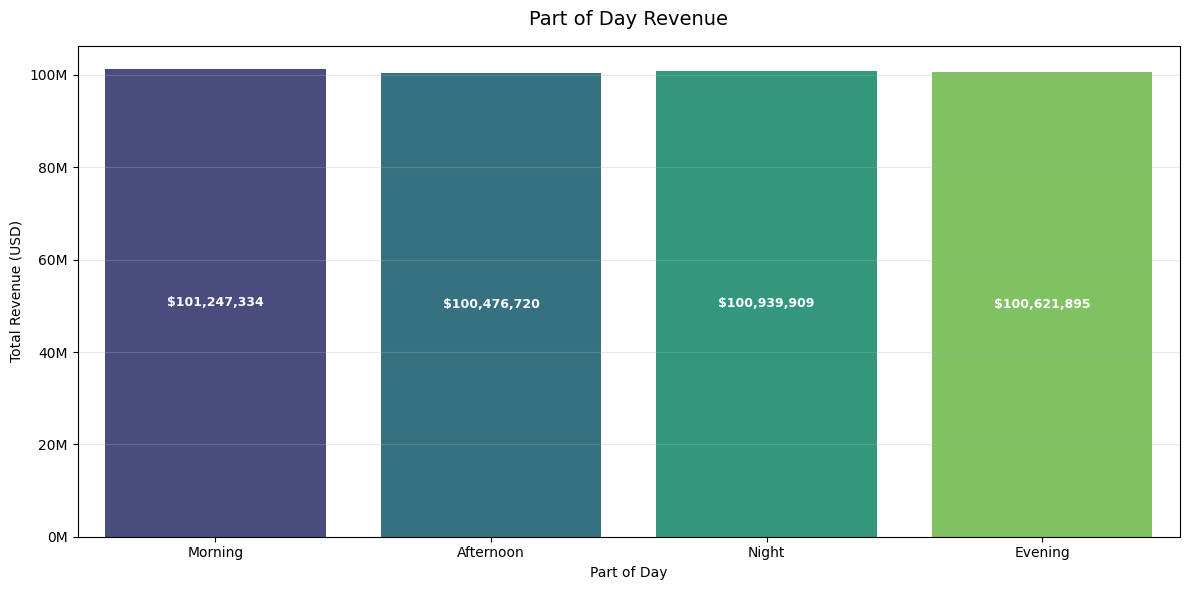

In [8]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    eda_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

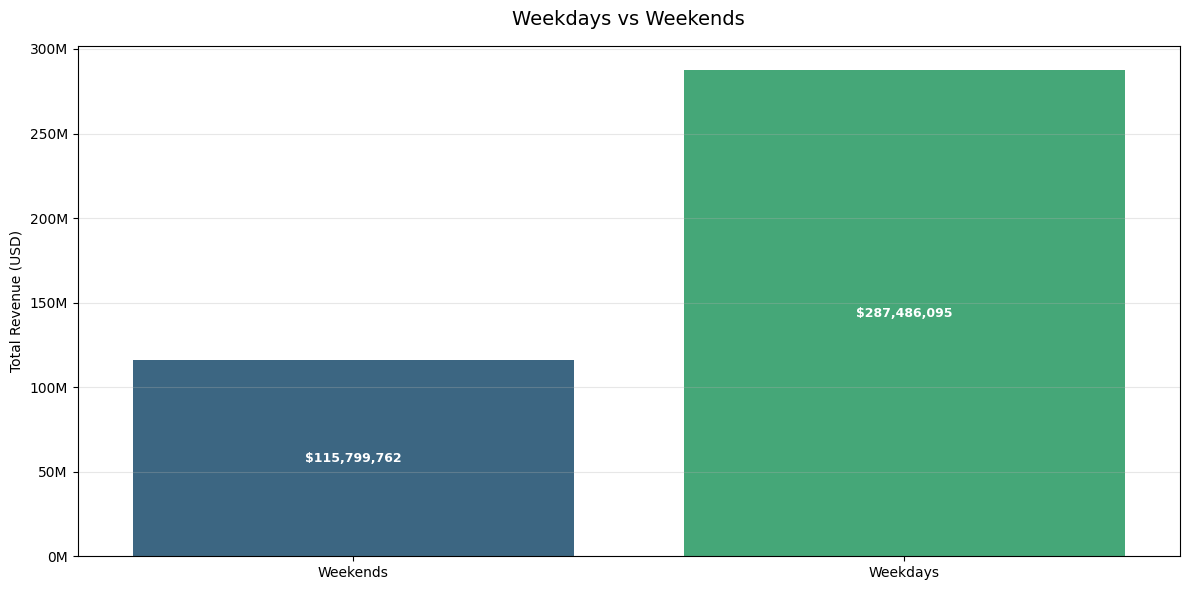

In [9]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    eda_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

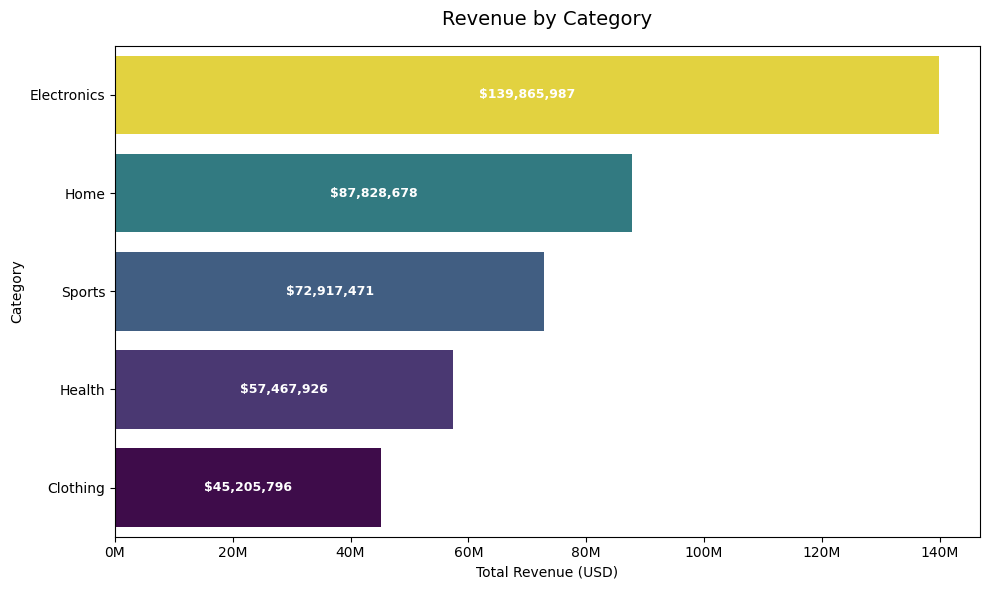

In [29]:
# 1.2.1 Revenue per Category

category_revenue = (
    eda_df.groupby('category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

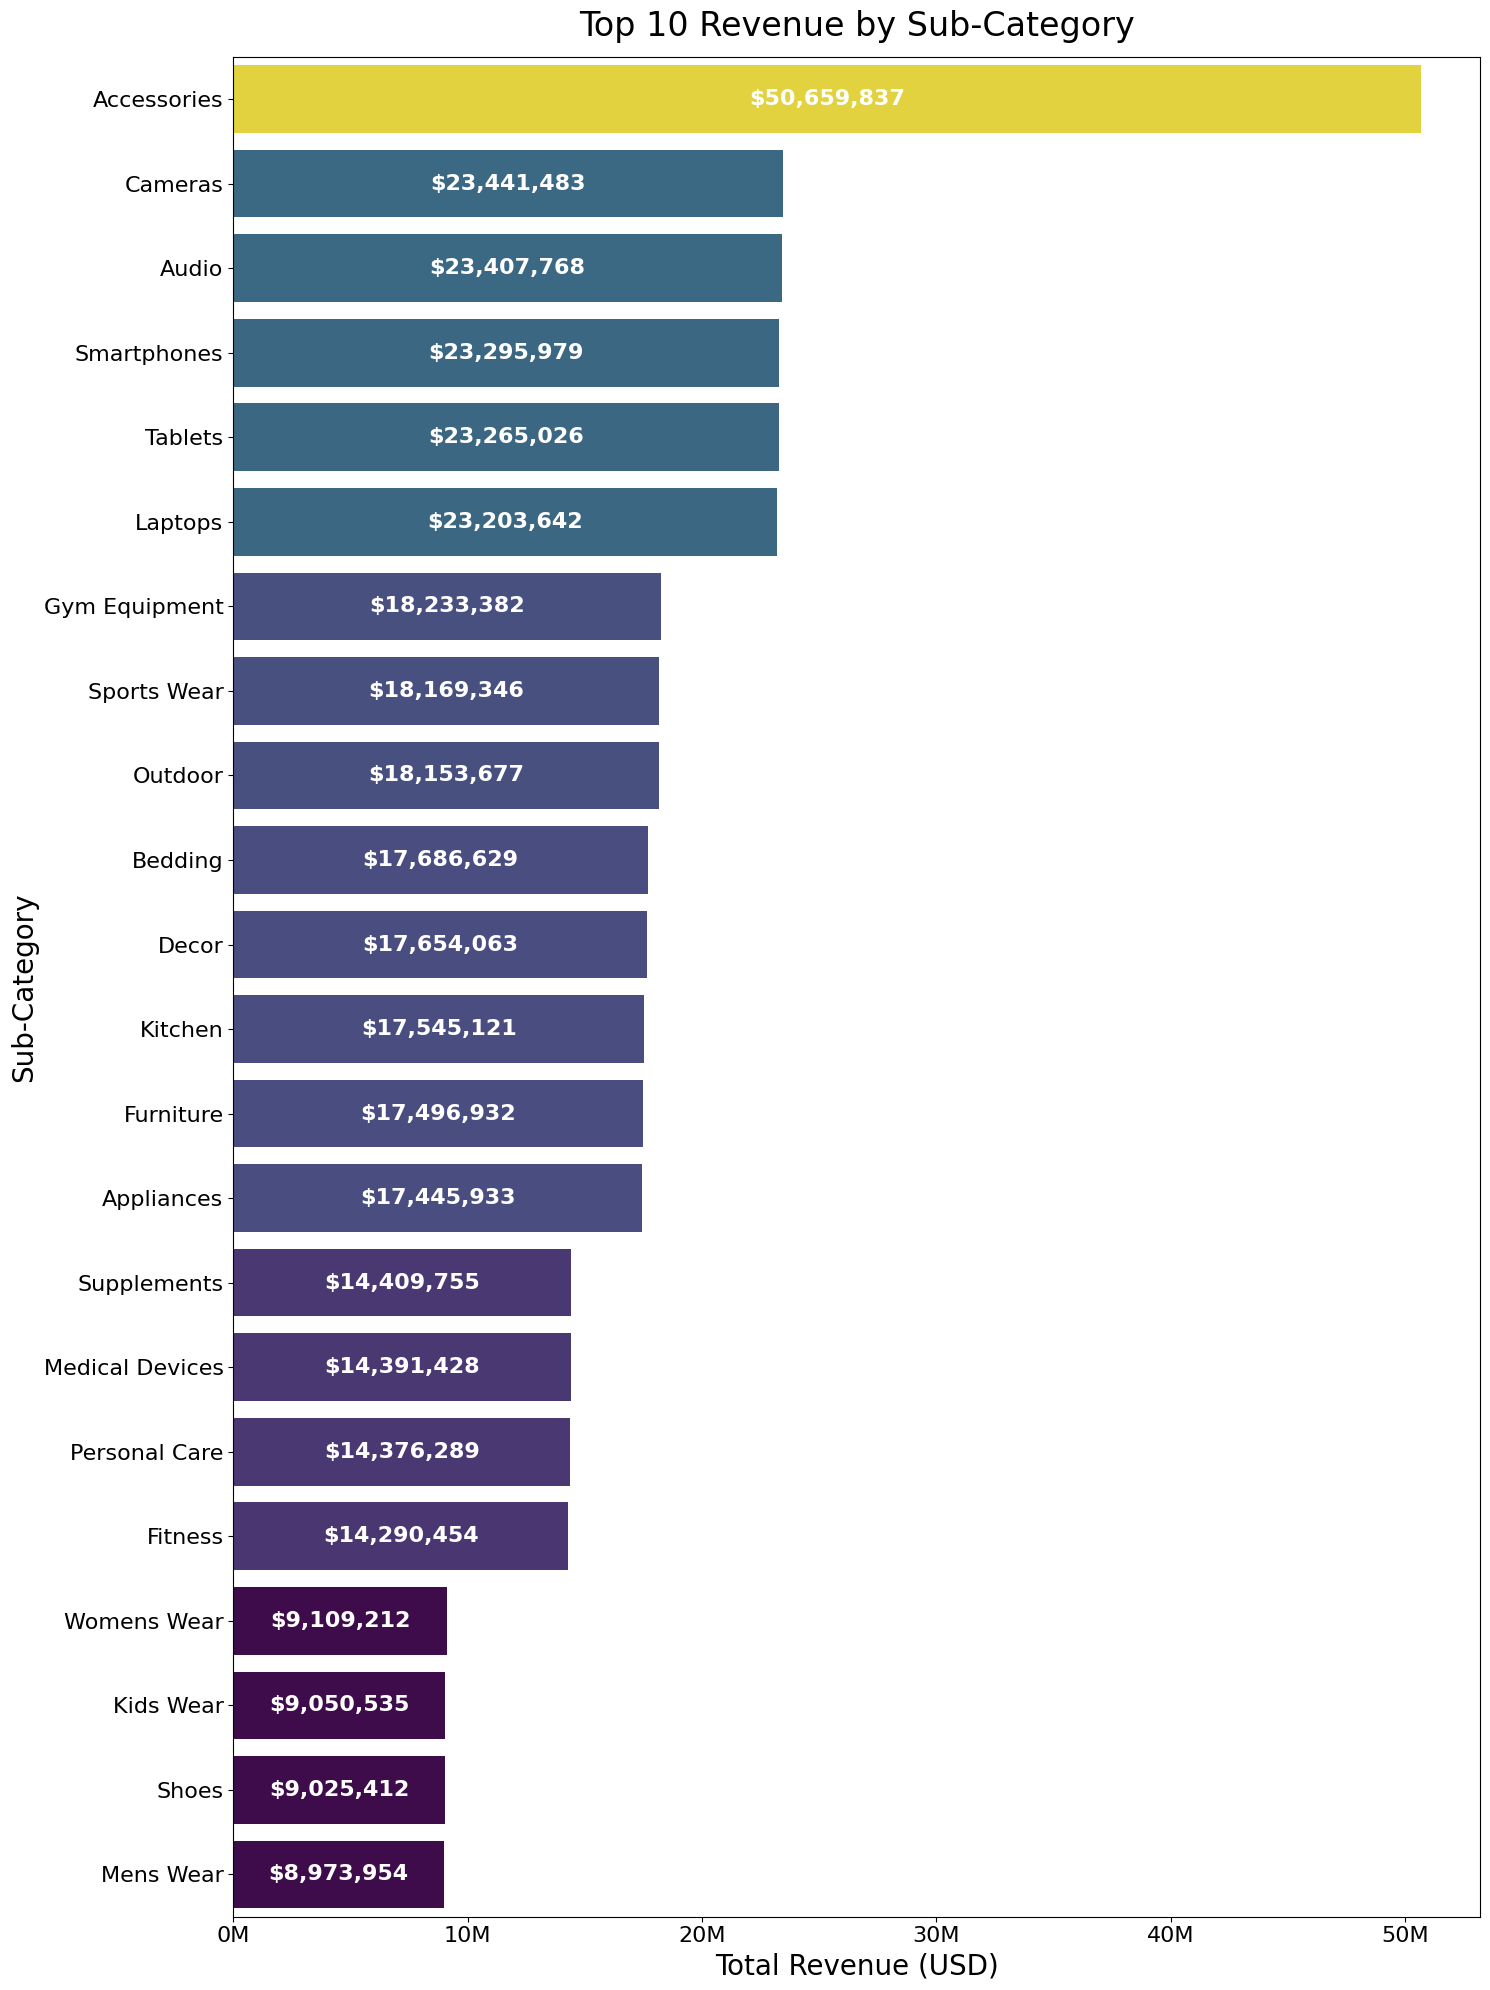

In [44]:
# 1.2.1 Top 10 Revenue Sub Category

subcategory_revenue = (
    eda_df.groupby('sub_category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

## 1.3 Revenue by Country

## 1.4 Revenue by Order Value Segment

## 1.5 Top 10 Customers with Highest Revenue

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)